# Unsupervised Dimensionality Reduction via Principal Component Analysis (PCA)

## 1. Introduction to PCA

Unlike **feature selection** (which maintains original features), **feature extraction** transforms or projects data onto a new feature space.

**Principal Component Analysis (PCA)** is an unsupervised linear transformation technique used for feature extraction and dimensionality reduction. It compresses data while maintaining most of the relevant information, improving computational efficiency and reducing the "curse of dimensionality."

PCA identifies patterns based on feature correlation. It aims to find the directions of **maximum variance** in high-dimensional data and projects it onto a new subspace with fewer dimensions. The new orthogonal axes (principal components) are the directions of maximum variance.

If we have a feature vector $\mathbf{x} \in \mathbb{R}^d$, it is transformed by a projection matrix $W \in \mathbb{R}^{d \times k}$ resulting in an output vector $\mathbf{z} \in \mathbb{R}^k$:


$$\mathbf{x}W = \mathbf{z}$$

### The 7 Main Steps of PCA:

1. Standardize the $d$-dimensional dataset.
2. Construct the covariance matrix.
3. Decompose the covariance matrix into its eigenvectors and eigenvalues.
4. Sort the eigenvalues in decreasing order to rank the corresponding eigenvectors.
5. Select $k$ eigenvectors, which correspond to the $k$ largest eigenvalues (where $k$ is the dimensionality of the new feature subspace, $k \le d$).
6. Construct a projection matrix, $W$, from the "top" $k$ eigenvectors.
7. Transform the $d$-dimensional input dataset, $X$, using the projection matrix $W$ to obtain the new $k$-dimensional feature subspace.

<p align="center">
  <img src="https://raw.githubusercontent.com/rasbt/machine-learning-book/main/ch05/figures/05_01.png" width="600">
</p>


---

## 2. Extracting Principal Components Step-by-Step (Manual Implementation)

### Step 1: Standardizing the Data

First, we load the Wine dataset, split it into training and test sets (70/30), and standardize it to unit variance.

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Load the Wine dataset
df_wine = pd.read_csv(
    'https://archive.ics.uci.edu/ml/machine-learning-databases/wine/wine.data',
    header=None
)

# Split into features (X) and target labels (y)
X, y = df_wine.iloc[:, 1:].values, df_wine.iloc[:, 0].values

# Split into train and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, stratify=y, random_state=0
)

# Standardize the features
sc = StandardScaler()
X_train_std = sc.fit_transform(X_train)
X_test_std = sc.transform(X_test)

### Steps 2 & 3: Covariance Matrix and Eigendecomposition

The covariance between two features $j$ and $k$ is calculated as:


$$\sigma_{jk} = \frac{1}{n-1} \sum_{i=1}^{n} \left( x_j^{(i)} - \mu_j \right) \left( x_k^{(i)} - \mu_k \right)$$

An eigenvector $\mathbf{v}$ and eigenvalue $\lambda$ of the covariance matrix $\Sigma$ satisfy:


$$\Sigma \mathbf{v} = \lambda \mathbf{v}$$

We can use NumPy to calculate the covariance matrix and obtain the eigenpairs.

In [ ]:
import numpy as np

# Construct the covariance matrix
cov_mat = np.cov(X_train_std.T)

# Decompose into eigenvalues and eigenvectors
eigen_vals, eigen_vecs = np.linalg.eig(cov_mat)

print('\nEigenvalues \n', eigen_vals)


Eigenvalues 
 [4.84274532 2.41602459 1.54845825 0.96120438 0.84166161 0.6620634
 0.51828472 0.34650377 0.3131368  0.10754642 0.21357215 0.15362835
 0.1808613 ]


### Step 4: Total and Explained Variance

To reduce dimensionality, we want to select the principal components that contain most of the information (variance). The **explained variance ratio** of an eigenvalue $\lambda_j$ is the fraction of its eigenvalue to the sum of all eigenvalues:

$$Explained\ variance\ ratio = \frac{\lambda_j}{\sum_{j=1}^{d} \lambda_j}$$

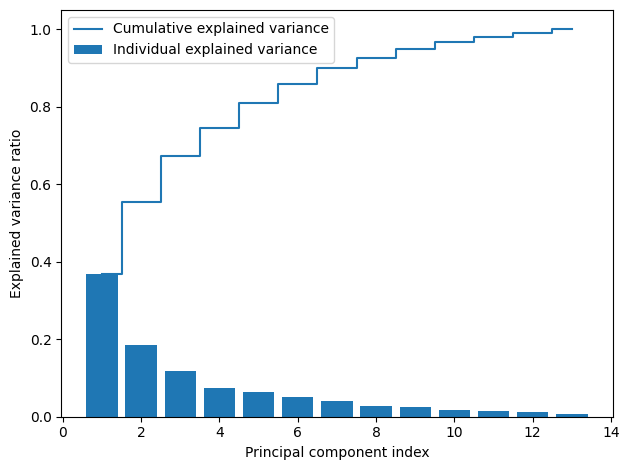

In [ ]:
import matplotlib.pyplot as plt

# Calculate explained variance ratios
tot = sum(eigen_vals)
var_exp = [(i / tot) for i in sorted(eigen_vals, reverse=True)]
cum_var_exp = np.cumsum(var_exp)

# Plot explained variance
plt.bar(range(1, 14), var_exp, align='center', label='Individual explained variance')
plt.step(range(1, 14), cum_var_exp, where='mid', label='Cumulative explained variance')
plt.ylabel('Explained variance ratio')
plt.xlabel('Principal component index')
plt.legend(loc='best')
plt.tight_layout()
plt.show()

### Steps 5 & 6: Feature Transformation and Projection Matrix

We sort the eigenpairs and construct the projection matrix $W$ from the top 2 eigenvectors (which capture ~60% of the variance in this dataset).

In [ ]:
# Make a list of (eigenvalue, eigenvector) tuples
eigen_pairs = [(np.abs(eigen_vals[i]), eigen_vecs[:, i]) for i in range(len(eigen_vals))]

# Sort the tuples from high to low
eigen_pairs.sort(key=lambda k: k[0], reverse=True)

# Construct the projection matrix W from the top 2 eigenvectors
w = np.hstack((eigen_pairs[0][1][:, np.newaxis],
               eigen_pairs[1][1][:, np.newaxis]))

print('Matrix W:\n', w)

Matrix W:
 [[-0.13724218  0.50303478]
 [ 0.24724326  0.16487119]
 [-0.02545159  0.24456476]
 [ 0.20694508 -0.11352904]
 [-0.15436582  0.28974518]
 [-0.39376952  0.05080104]
 [-0.41735106 -0.02287338]
 [ 0.30572896  0.09048885]
 [-0.30668347  0.00835233]
 [ 0.07554066  0.54977581]
 [-0.32613263 -0.20716433]
 [-0.36861022 -0.24902536]
 [-0.29669651  0.38022942]]


### Step 7: Transforming the Dataset

We map the $124 \times 13$-dimensional training dataset onto the two principal components by calculating the matrix dot product: $\mathbf{X}' = \mathbf{X}W$.

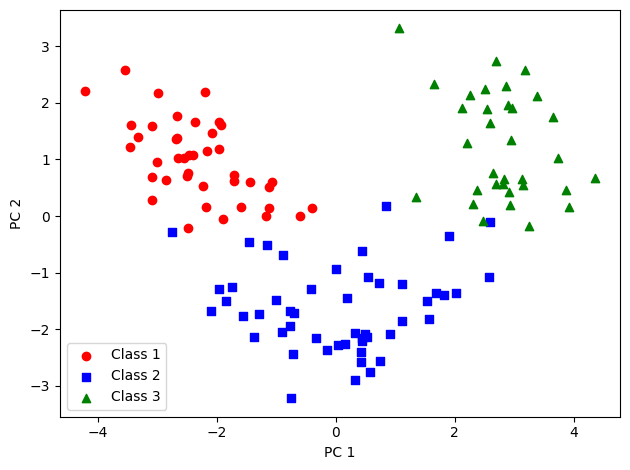

In [ ]:
# Transform the training dataset
X_train_pca = X_train_std.dot(w)

# Visualize the transformed dataset
colors = ['r', 'b', 'g']
markers = ['o', 's', '^']

for l, c, m in zip(np.unique(y_train), colors, markers):
    plt.scatter(X_train_pca[y_train == l, 0],
                X_train_pca[y_train == l, 1],
                c=c, label=f'Class {l}', marker=m)

plt.xlabel('PC 1')
plt.ylabel('PC 2')
plt.legend(loc='lower left')
plt.tight_layout()
plt.show()

---

## 3. PCA in scikit-learn

We can perform the exact same steps much more conveniently using scikit-learn's `PCA` transformer class. We will also train a Logistic Regression model on the transformed data and plot the decision boundaries.

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1256: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(


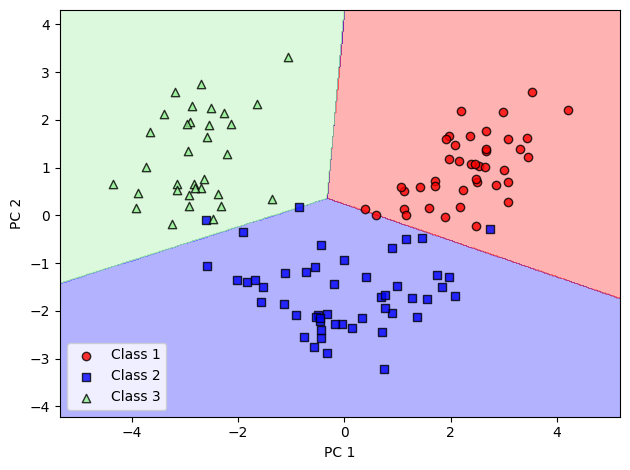

In [ ]:
from matplotlib.colors import ListedColormap
from sklearn.linear_model import LogisticRegression
from sklearn.decomposition import PCA

# Helper function to plot decision regions
def plot_decision_regions(X, y, classifier, test_idx=None, resolution=0.02):
    markers = ('o', 's', '^', 'v', '<')
    colors = ('red', 'blue', 'lightgreen', 'gray', 'cyan')
    cmap = ListedColormap(colors[:len(np.unique(y))])

    x1_min, x1_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    x2_min, x2_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx1, xx2 = np.meshgrid(np.arange(x1_min, x1_max, resolution),
                           np.arange(x2_min, x2_max, resolution))

    lab = classifier.predict(np.array([xx1.ravel(), xx2.ravel()]).T)
    lab = lab.reshape(xx1.shape)
    plt.contourf(xx1, xx2, lab, alpha=0.3, cmap=cmap)
    plt.xlim(xx1.min(), xx1.max())
    plt.ylim(xx2.min(), xx2.max())

    for idx, cl in enumerate(np.unique(y)):
        plt.scatter(x=X[y == cl, 0], y=X[y == cl, 1],
                    alpha=0.8, c=colors[idx],
                    marker=markers[idx], label=f'Class {cl}',
                    edgecolor='black')

# Initialize PCA and Logistic Regression
pca = PCA(n_components=2)
lr = LogisticRegression(multi_class='ovr', random_state=1, solver='lbfgs')

# Dimensionality reduction and model fitting
X_train_pca = pca.fit_transform(X_train_std)
X_test_pca = pca.transform(X_test_std)
lr.fit(X_train_pca, y_train)

# Plot decision regions for training data
plot_decision_regions(X_train_pca, y_train, classifier=lr)
plt.xlabel('PC 1')
plt.ylabel('PC 2')
plt.legend(loc='lower left')
plt.tight_layout()
plt.show()

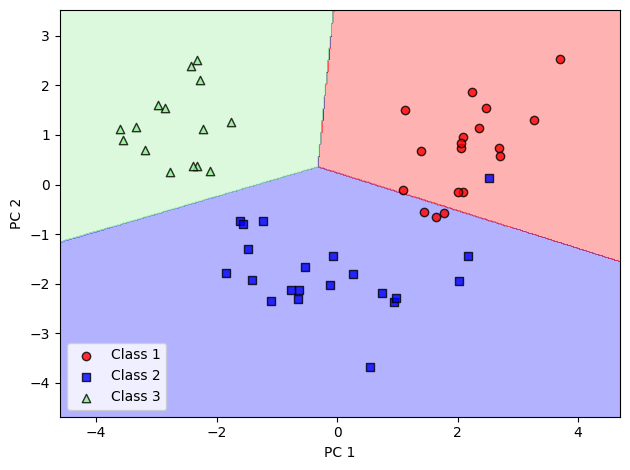

In [ ]:
plot_decision_regions(X_test_pca, y_test, classifier=lr)
plt.xlabel('PC 1')
plt.ylabel('PC 2')
plt.legend(loc='lower left')
plt.tight_layout()
plt.show()

*(Note: If you want to access the explained variance ratio directly from `sklearn`, you can instantiate `PCA(n_components=None)` and call the `pca.explained_variance_ratio_` attribute.)*

---

## 4. Assessing Feature Contributions (Loadings)

We are often interested to know how much each original feature contributes to a given principal component. These contributions are called **loadings**. They can be computed by scaling the eigenvectors by the square root of the eigenvalues:

$$Loadings = Eigenvectors \times \sqrt{Eigenvalues}$$

### Plot 'loadings' to analyze the correlation between original features and the principal components.

**Feature correlations with the first principal component.**

In [ ]:
# Compute feature loadings
loadings = eigen_vecs * np.sqrt(eigen_vals)

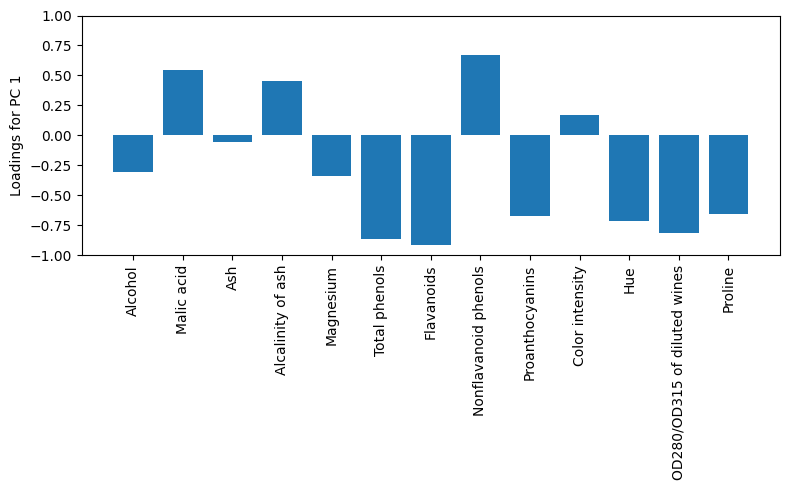

In [ ]:
import matplotlib.pyplot as plt

# These are the actual 13 feature names for the UCI Wine dataset
wine_features = [
    'Alcohol', 'Malic acid', 'Ash', 'Alcalinity of ash', 'Magnesium',
    'Total phenols', 'Flavanoids', 'Nonflavanoid phenols',
    'Proanthocyanins', 'Color intensity', 'Hue',
    'OD280/OD315 of diluted wines', 'Proline'
]

fig, ax = plt.subplots(figsize=(8, 5))

# Use the explicit text labels for the x-axis
ax.bar(wine_features, loadings[:, 0], align='center')

ax.set_ylabel('Loadings for PC 1')

# Rotate labels 90 degrees so they don't overlap
plt.xticks(rotation=90)

plt.ylim([-1, 1])
plt.tight_layout()
plt.show()

**Feature correlations to the first principal component using scikit-learn.**

In [ ]:
sklearn_loadings = pca.components_.T * np.sqrt(pca.explained_variance_)

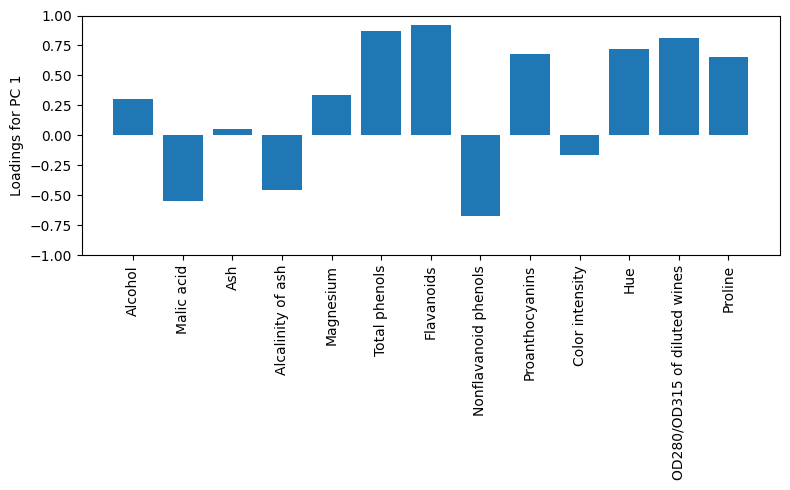

In [ ]:
import matplotlib.pyplot as plt

# These are the actual 13 feature names for the UCI Wine dataset
wine_features = [
    'Alcohol', 'Malic acid', 'Ash', 'Alcalinity of ash', 'Magnesium',
    'Total phenols', 'Flavanoids', 'Nonflavanoid phenols',
    'Proanthocyanins', 'Color intensity', 'Hue',
    'OD280/OD315 of diluted wines', 'Proline'
]

fig, ax = plt.subplots(figsize=(8, 5))

# Use the explicit text labels for the x-axis
ax.bar(wine_features, sklearn_loadings[:, 0], align='center')

ax.set_ylabel('Loadings for PC 1')

# Rotate labels 90 degrees so they don't overlap
plt.xticks(rotation=90)

plt.ylim([-1, 1])
plt.tight_layout()
plt.show()